In [1]:
import os, glob, json, re, random, warnings
import numpy as np
import pandas as pd
import librosa, librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedGroupKFold
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

INPUT_DIR = os.environ.get("INPUT_DIR", "/kaggle/input")
WORK_DIR  = os.environ.get("WORK_DIR", "/kaggle/working")
FIG_DIR   = os.path.join(WORK_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)

# ---- Pipeline configuration (kept in one place so it can be reported) ----
CFG = dict(
    sr=8000,            # target sampling rate (ICBHI files are 4 kHz / 10 kHz / 44.1 kHz)
    band=(50, 2000),    # band-pass range (Hz): lung sounds, crackles & wheezes live here
    seg_sec=4.0,        # fixed segment length (s); mean ICBHI cycle ≈ 2.7 s
    min_cycle_sec=0.3,  # discard tiny/erroneous annotations
    n_fft=512, hop=128, n_mels=64, fmin=50, fmax=4000,
    n_mfcc=20,
    trim_silence=False, # ICBHI cycles are already annotated; set True for cough datasets (Coswara/COUGHVID)
    seed=SEED,
)
CFG["n_frames"] = int(np.ceil(CFG["seg_sec"] * CFG["sr"] / CFG["hop"])) + 1
print(CFG)

{'sr': 8000, 'band': (50, 2000), 'seg_sec': 4.0, 'min_cycle_sec': 0.3, 'n_fft': 512, 'hop': 128, 'n_mels': 64, 'fmin': 50, 'fmax': 4000, 'n_mfcc': 20, 'trim_silence': False, 'seed': 42, 'n_frames': 251}


# 01 — Dataset Acquisition & Preprocessing Pipeline (ICBHI 2017)
**ICT 4442 Mini Project — Explainable Respiratory Disease Screening from Respiratory Audio**

**Owner:** Gaurav Venigalla (pipeline) · Abhigyaan Singh (EDA)

**Input:** Kaggle dataset `vbookshelf/respiratory-sound-database` (ICBHI 2017 Respiratory Sound Database) — click **Add Input → Datasets** and search "Respiratory Sound Database".

**What this notebook does**
1. Locates audio (`.wav`), cycle annotations (`.txt`) and `patient_diagnosis.csv`.
2. Parses filename metadata (patient, chest location, acquisition mode, device).
3. Maps the 8 patient diagnoses to the 3 screening classes: **Healthy / Chronic / Non-chronic**.
4. Loads audio → resamples to 8 kHz → band-pass filters (50–2000 Hz) → segments into annotated respiratory cycles → fixes length to 4 s (cyclic padding / cropping) → peak-normalises.
5. Extracts **log-mel spectrograms** (for deep models) and **MFCC + spectral hand-crafted features** (for the classical baseline).
6. Creates a **patient-independent, stratified train/val/test split** (no patient appears in two splits → no data leakage).
7. Runs EDA plots and saves everything to `/kaggle/working/` for the model notebooks.

All model notebooks use the **same split and same metrics** (common evaluation protocol).

## 1. Locate the dataset

In [2]:
diag_files = glob.glob(os.path.join(INPUT_DIR, "**", "patient_diagnosis.csv"), recursive=True)
assert diag_files, "patient_diagnosis.csv not found — did you add the 'Respiratory Sound Database' input?"
DIAG_CSV = diag_files[0]

wav_paths = {}
for p in glob.glob(os.path.join(INPUT_DIR, "**", "*.wav"), recursive=True):
    wav_paths.setdefault(os.path.basename(p), p)   # de-duplicate by file name
print("diagnosis csv :", DIAG_CSV)
print("unique .wav   :", len(wav_paths))

diagnosis csv : /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv
unique .wav   : 920


## 2. Metadata: diagnoses, filename fields, cycle annotations

In [3]:
diag = pd.read_csv(DIAG_CSV, header=None, names=["patient", "diagnosis"])
diag = diag[pd.to_numeric(diag["patient"], errors="coerce").notna()]   # drop header row if present
diag["patient"] = diag["patient"].astype(int)
diag["diagnosis"] = diag["diagnosis"].str.strip()

GROUP = {
    "Healthy": "Healthy",
    "COPD": "Chronic", "Bronchiectasis": "Chronic", "Asthma": "Chronic",
    "URTI": "Non-chronic", "LRTI": "Non-chronic", "Pneumonia": "Non-chronic", "Bronchiolitis": "Non-chronic",
}
CLASSES = ["Healthy", "Chronic", "Non-chronic"]
diag["group"] = diag["diagnosis"].map(GROUP)
assert diag["group"].notna().all(), diag[diag["group"].isna()]
print(diag["diagnosis"].value_counts(), "\n")
print(diag["group"].value_counts())

diagnosis
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1
Name: count, dtype: int64 

group
Chronic        72
Non-chronic    28
Healthy        26
Name: count, dtype: int64


In [4]:
rows = []
for fname, wpath in sorted(wav_paths.items()):
    stem = fname[:-4]
    parts = stem.split("_")             # e.g. 101_1b1_Al_sc_Meditron
    if len(parts) < 5:
        continue
    txt = wpath[:-4] + ".txt"
    if not os.path.exists(txt):
        continue
    ann = pd.read_csv(txt, sep=r"\s+", header=None, names=["start", "end", "crackles", "wheezes"])
    for i, a in ann.iterrows():
        rows.append(dict(recording=stem, wav=wpath, patient=int(parts[0]), rec_idx=parts[1],
                         location=parts[2], mode=parts[3], device=parts[4], cycle=i,
                         start=float(a.start), end=float(a.end),
                         crackles=int(a.crackles), wheezes=int(a.wheezes)))
cycles = pd.DataFrame(rows)
cycles["duration"] = cycles["end"] - cycles["start"]
cycles["cycle_label"] = np.select(
    [(cycles.crackles == 0) & (cycles.wheezes == 0), (cycles.crackles == 1) & (cycles.wheezes == 0),
     (cycles.crackles == 0) & (cycles.wheezes == 1)], ["normal", "crackle", "wheeze"], "both")
cycles = cycles.merge(diag, on="patient", how="left")
cycles = cycles[cycles["duration"] >= CFG["min_cycle_sec"]].reset_index(drop=True)
cycles["label"] = cycles["group"].map({c: i for i, c in enumerate(CLASSES)})
print(f"{cycles.recording.nunique()} recordings, {cycles.patient.nunique()} patients, {len(cycles)} respiratory cycles")
cycles.head()

920 recordings, 126 patients, 6891 respiratory cycles


,recording,wav,patient,rec_idx,location,mode,device,cycle,start,end,crackles,wheezes,duration,cycle_label,diagnosis,group,label
0,101_1b1_Al_sc_Meditron,/kaggle/input/datasets/vbookshelf/respiratory-...,101,1b1,Al,sc,Meditron,0,0.036,0.579,0,0,0.543,normal,URTI,Non-chronic,2
1,101_1b1_Al_sc_Meditron,/kaggle/input/datasets/vbookshelf/respiratory-...,101,1b1,Al,sc,Meditron,1,0.579,2.450,0,0,1.871,normal,URTI,Non-chronic,2
2,101_1b1_Al_sc_Meditron,/kaggle/input/datasets/vbookshelf/respiratory-...,101,1b1,Al,sc,Meditron,2,2.450,3.893,0,0,1.443,normal,URTI,Non-chronic,2
3,101_1b1_Al_sc_Meditron,/kaggle/input/datasets/vbookshelf/respiratory-...,101,1b1,Al,sc,Meditron,3,3.893,5.793,0,0,1.900,normal,URTI,Non-chronic,2
4,101_1b1_Al_sc_Meditron,/kaggle/input/datasets/vbookshelf/respiratory-...,101,1b1,Al,sc,Meditron,4,5.793,7.521,0,0,1.728,normal,URTI,Non-chronic,2


## 3. Patient-independent stratified split (≈70 / 15 / 15 by patient)
Splitting by **patient** (not by cycle) is essential: cycles from the same person are highly correlated, and a random cycle split inflates accuracy.

In [5]:
pat = cycles.groupby("patient")["group"].first().reset_index()
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
trval_idx, test_idx = next(sgkf.split(pat, pat["group"], groups=pat["patient"]))
test_p = set(pat.iloc[test_idx].patient)
trval = pat.iloc[trval_idx].reset_index(drop=True)
sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
tr_idx, va_idx = next(sgkf2.split(trval, trval["group"], groups=trval["patient"]))
val_p = set(trval.iloc[va_idx].patient)

cycles["split"] = np.where(cycles.patient.isin(test_p), "test",
                  np.where(cycles.patient.isin(val_p), "val", "train"))
assert not (set(cycles[cycles.split=="train"].patient) & test_p), "patient leakage!"
print(pd.crosstab(cycles.drop_duplicates("patient").group, cycles.drop_duplicates("patient").split, margins=True), "\n")
print(pd.crosstab(cycles.group, cycles.split, margins=True))

split        test  train  val  All
group                             
Chronic         6     55   11   72
Healthy         9     14    3   26
Non-chronic     3     21    4   28
All            18     90   18  126 

split        test  train   val   All
group                               
Chronic       683   3636  1535  5854
Healthy        99    181    41   321
Non-chronic    52    590    74   716
All           834   4407  1650  6891


## 4. Signal processing & feature extraction
* **Resampling** to 8 kHz (common rate across the three stethoscopes / devices)
* **Butterworth band-pass** 50–2000 Hz (removes heart-sound/DC drift below and hiss above)
* **Segmentation** into annotated respiratory cycles → fixed **4 s** (cyclic repeat-padding if shorter, centre-crop if longer)
* **Peak normalisation** (removes device gain differences)
* **Log-mel spectrogram** 64 mel bands × 251 frames (deep models)
* **Hand-crafted vector**: 20 MFCC + 20 Δ-MFCC (mean & std), spectral centroid / bandwidth / roll-off / flatness / contrast, ZCR, RMS, cycle duration (classical baseline)

In [6]:
SOS = butter(5, CFG["band"], btype="bandpass", fs=CFG["sr"], output="sos")

def fix_length(y, n):
    if len(y) >= n:
        s = (len(y) - n) // 2
        return y[s:s + n]
    reps = int(np.ceil(n / max(len(y), 1)))
    return np.tile(y, reps)[:n]

def trim_silence(y, top_db=35):
    yt, _ = librosa.effects.trim(y, top_db=top_db)
    return yt if len(yt) > 0.2 * CFG["sr"] else y

def handcrafted(y, sr, duration):
    mf = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CFG["n_mfcc"], n_fft=CFG["n_fft"], hop_length=CFG["hop"], n_mels=CFG["n_mels"], fmax=CFG["fmax"])
    d = librosa.feature.delta(mf)
    S = np.abs(librosa.stft(y, n_fft=CFG["n_fft"], hop_length=CFG["hop"]))
    cent = librosa.feature.spectral_centroid(S=S, sr=sr)
    bw = librosa.feature.spectral_bandwidth(S=S, sr=sr)
    roll = librosa.feature.spectral_rolloff(S=S, sr=sr)
    flat = librosa.feature.spectral_flatness(S=S)
    con = librosa.feature.spectral_contrast(S=S, sr=sr, fmin=100, n_bands=4)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=CFG["n_fft"], hop_length=CFG["hop"])
    rms = librosa.feature.rms(S=S, frame_length=CFG["n_fft"])
    feats = [mf.mean(1), mf.std(1), d.mean(1), d.std(1)]
    for f in (cent, bw, roll, flat, zcr, rms):
        feats += [f.mean(1), f.std(1)]
    feats += [con.mean(1), np.array([duration])]
    return np.concatenate(feats).astype(np.float32)

def feature_names():
    n = CFG["n_mfcc"]
    names = [f"mfcc{i}_mean" for i in range(n)] + [f"mfcc{i}_std" for i in range(n)]
    names += [f"dmfcc{i}_mean" for i in range(n)] + [f"dmfcc{i}_std" for i in range(n)]
    for f in ("centroid", "bandwidth", "rolloff", "flatness", "zcr", "rms"):
        names += [f"{f}_mean", f"{f}_std"]
    names += [f"contrast_b{i}" for i in range(5)] + ["cycle_duration"]
    return names

def process_recording(wav, segs):
    y, sr = librosa.load(wav, sr=CFG["sr"], mono=True)
    y = sosfiltfilt(SOS, y).astype(np.float32)
    n = int(CFG["seg_sec"] * sr)
    mels, hcs = [], []
    for start, end in segs:
        seg = y[int(start * sr):int(end * sr)]
        if len(seg) < int(0.1 * sr):
            seg = np.zeros(int(0.1 * sr), dtype=np.float32) + 1e-6
        if CFG["trim_silence"]:
            seg = trim_silence(seg)
        hc = handcrafted(seg / (np.abs(seg).max() + 1e-8), sr, end - start)
        seg = fix_length(seg, n)
        seg = seg / (np.abs(seg).max() + 1e-8)
        m = librosa.feature.melspectrogram(y=seg, sr=sr, n_fft=CFG["n_fft"], hop_length=CFG["hop"],
                                           n_mels=CFG["n_mels"], fmin=CFG["fmin"], fmax=CFG["fmax"])
        mels.append(librosa.power_to_db(m, ref=np.max, top_db=80.0).astype(np.float16))
        hcs.append(hc)
    return mels, hcs

In [7]:
groups = list(cycles.groupby("wav", sort=False))
out = Parallel(n_jobs=-1, verbose=5)(
    delayed(process_recording)(wav, list(zip(g.start, g.end))) for wav, g in groups)

order = np.concatenate([g.index.values for _, g in groups])
logmel = np.stack([m for mels, _ in out for m in mels])
hand = np.stack([h for _, hcs in out for h in hcs])
inv = np.empty_like(order); inv[order] = np.arange(len(order))
logmel, hand = logmel[inv], hand[inv]          # restore the row order of `cycles`
print("log-mel:", logmel.shape, logmel.dtype, "| hand-crafted:", hand.shape)
assert logmel.shape[0] == hand.shape[0] == len(cycles)
assert np.isfinite(hand).all()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   37.1s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:   40.8s
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:   46.7s
[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:   54.4s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 640 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 874 tasks      | elapsed:  1.5min


log-mel: (6891, 64, 251) float16 | hand-crafted: (6891, 98)


[Parallel(n_jobs=-1)]: Done 920 out of 920 | elapsed:  1.6min finished


## 5. Save processed data (used by all model notebooks)

In [8]:
np.save(os.path.join(WORK_DIR, "logmel.npy"), logmel)
np.save(os.path.join(WORK_DIR, "handcrafted.npy"), hand)
cycles.drop(columns=["wav"]).to_csv(os.path.join(WORK_DIR, "segments_meta.csv"), index=False)
with open(os.path.join(WORK_DIR, "prep_config.json"), "w") as f:
    json.dump(dict(CFG, classes=CLASSES, feature_names=feature_names()), f, indent=1)
print(sorted(os.listdir(WORK_DIR)))

['__notebook__.ipynb', 'figures', 'handcrafted.npy', 'logmel.npy', 'prep_config.json', 'segments_meta.csv']


## 6. Exploratory data analysis

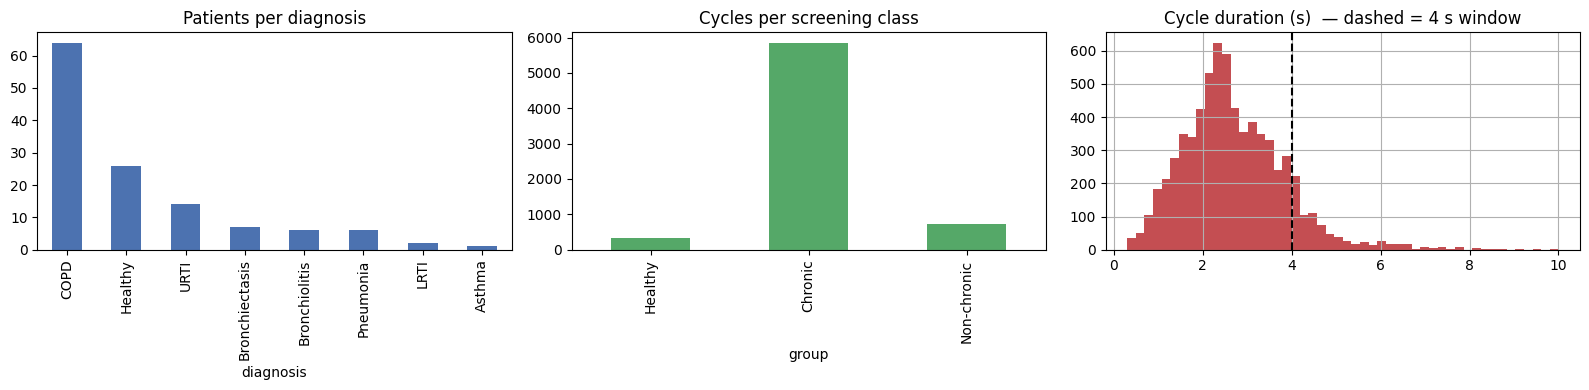

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
diag["diagnosis"].value_counts().plot.bar(ax=ax[0], color="#4C72B0", title="Patients per diagnosis")
cycles["group"].value_counts().reindex(CLASSES).plot.bar(ax=ax[1], color="#55A868", title="Cycles per screening class")
cycles["duration"].clip(upper=10).hist(bins=50, ax=ax[2], color="#C44E52")
ax[2].axvline(CFG["seg_sec"], ls="--", c="k"); ax[2].set_title("Cycle duration (s)  — dashed = 4 s window")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "eda_distribution.png"), dpi=130); plt.show()

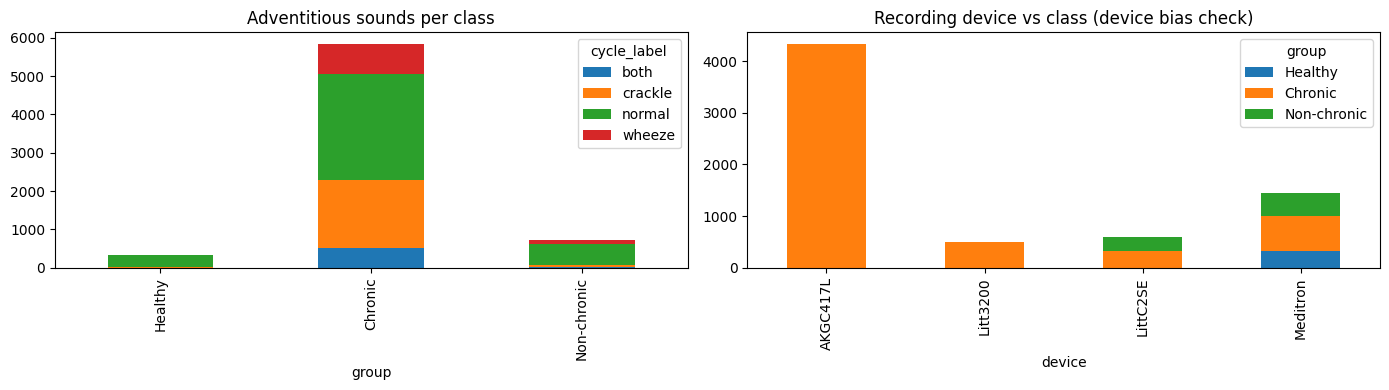

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
pd.crosstab(cycles.group, cycles.cycle_label).reindex(CLASSES).plot.bar(stacked=True, ax=ax[0], title="Adventitious sounds per class")
pd.crosstab(cycles.device, cycles.group)[CLASSES].plot.bar(stacked=True, ax=ax[1], title="Recording device vs class (device bias check)")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "eda_cycles_devices.png"), dpi=130); plt.show()

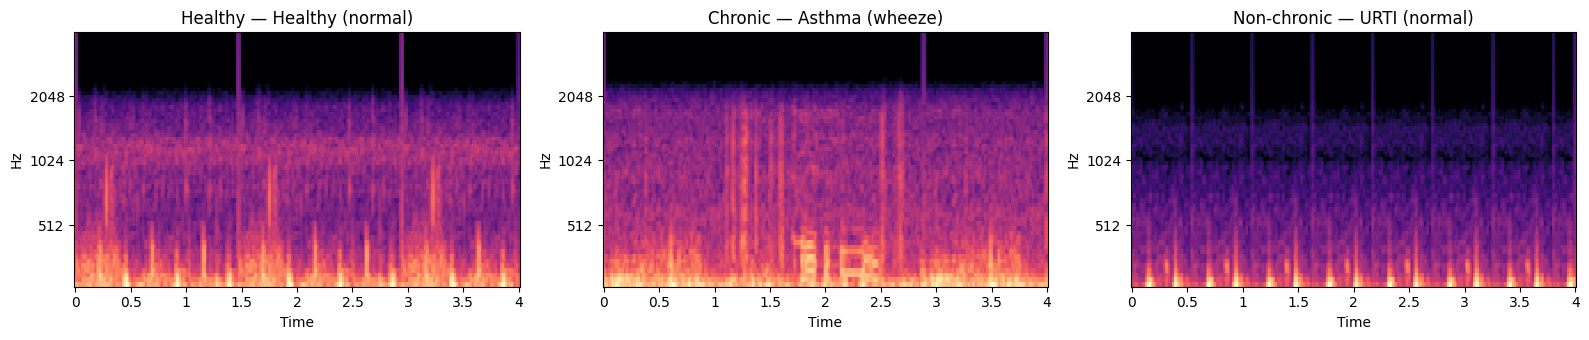

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))
for k, c in enumerate(CLASSES):
    i = cycles.index[cycles.group == c][0]
    librosa.display.specshow(logmel[i].astype(np.float32), sr=CFG["sr"], hop_length=CFG["hop"],
                             x_axis="time", y_axis="mel", fmin=CFG["fmin"], fmax=CFG["fmax"], ax=ax[k])
    ax[k].set_title(f"{c} — {cycles.diagnosis[i]} ({cycles.cycle_label[i]})")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "eda_example_logmel.png"), dpi=130); plt.show()

In [12]:
summary = dict(recordings=int(cycles.recording.nunique()), patients=int(cycles.patient.nunique()),
               cycles=int(len(cycles)),
               cycles_per_split=cycles.split.value_counts().to_dict(),
               patients_per_split=cycles.drop_duplicates("patient").split.value_counts().to_dict(),
               cycles_per_class=cycles.group.value_counts().to_dict())
print(json.dumps(summary, indent=1))
json.dump(summary, open(os.path.join(WORK_DIR, "data_summary.json"), "w"), indent=1)

{
 "recordings": 920,
 "patients": 126,
 "cycles": 6891,
 "cycles_per_split": {
  "train": 4407,
  "val": 1650,
  "test": 834
 },
 "patients_per_split": {
  "train": 90,
  "val": 18,
  "test": 18
 },
 "cycles_per_class": {
  "Chronic": 5854,
  "Non-chronic": 716,
  "Healthy": 321
 }
}
